In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (283085, 19)
Test shape: (177063, 19)


In [7]:
number_columns = [
    "high", "low", "momentum_index", "beta_indicator", "risk_premium",
    "volatility_factor", "technical_score", "oscillator_value",
    "liquidity_ratio", "open", "quant_index", "trend_strength",
    "market_sentiment", "volume", "alpha_signal",
]

In [8]:
for col in number_columns:
    train[col] = train[col].replace(0, np.nan)
    test[col] = test[col].replace(0, np.nan)

medians = train[number_columns].median()

train[number_columns] = train[number_columns].fillna(medians)
test[number_columns] = test[number_columns].fillna(medians)

In [9]:
train = train[train["close"].notna() & (train["close"] != 0)]
test = test[test["close"].notna() & (test["close"] != 0)]
print("Train rows after cleaning:", train.shape[0])
print("Test rows after cleaning:", test.shape[0])

Train rows after cleaning: 280078
Test rows after cleaning: 176495


In [10]:
symbol_columns = []
for value in train["symbols"].unique():
    name = "symbol_" + value
    train[name] = (train["symbols"] == value).astype(int)
    test[name] = (test["symbols"] == value).astype(int)
    symbol_columns.append(name)

feature_columns = number_columns + symbol_columns

In [11]:
X_train = train[feature_columns].to_numpy(dtype=float)
y_train = train["close"].to_numpy(dtype=float)

X_test = test[feature_columns].to_numpy(dtype=float)
y_test = test["close"].to_numpy(dtype=float)

In [12]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

# scale the answer (close) too, we change it back before checking accuracy
y_mean = y_train.mean()
y_std = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

In [13]:
def predict(X, w):
    return X @ w


def cost(X, y, w):
    m = len(y)
    errors = predict(X, w) - y
    return (errors ** 2).sum() / (2 * m)


def r2_score(y_real, y_pred):
    ss_res = ((y_real - y_pred) ** 2).sum()
    ss_tot = ((y_real - y_real.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

In [14]:
learning_rate = 0.2
epochs = 300

w = np.zeros(X_train.shape[1])
m = len(y_train_scaled)

train_costs = []
test_costs = []
train_accs = []
test_accs = []

for epoch in range(1, epochs + 1):
    # one step of gradient descent
    errors = predict(X_train, w) - y_train_scaled
    gradient = (X_train.T @ errors) / m
    w = w - learning_rate * gradient

    # save the cost
    train_costs.append(cost(X_train, y_train_scaled, w))
    test_costs.append(cost(X_test, y_test_scaled, w))

    # save the accuracy on the real prices (change the scaling back)
    train_pred = predict(X_train, w) * y_std + y_mean
    test_pred = predict(X_test, w) * y_std + y_mean
    train_accs.append(r2_score(y_train, train_pred) * 100)
    test_accs.append(r2_score(y_test, test_pred) * 100)

    print(f"Epoch {epoch:3d} | cost: {train_costs[-1]:.5f} | "
          f"train accuracy: {train_accs[-1]:.2f}% | "
          f"test accuracy: {test_accs[-1]:.2f}%")

Epoch   1 | cost: 0.07929 | train accuracy: 84.14% | test accuracy: 72.59%
Epoch   2 | cost: 0.06111 | train accuracy: 87.78% | test accuracy: 74.98%
Epoch   3 | cost: 0.05481 | train accuracy: 89.04% | test accuracy: 73.80%
Epoch   4 | cost: 0.05064 | train accuracy: 89.87% | test accuracy: 73.36%
Epoch   5 | cost: 0.04748 | train accuracy: 90.50% | test accuracy: 73.15%
Epoch   6 | cost: 0.04491 | train accuracy: 91.02% | test accuracy: 73.18%
Epoch   7 | cost: 0.04270 | train accuracy: 91.46% | test accuracy: 73.39%
Epoch   8 | cost: 0.04076 | train accuracy: 91.85% | test accuracy: 73.73%
Epoch   9 | cost: 0.03901 | train accuracy: 92.20% | test accuracy: 74.17%
Epoch  10 | cost: 0.03740 | train accuracy: 92.52% | test accuracy: 74.67%
Epoch  11 | cost: 0.03591 | train accuracy: 92.82% | test accuracy: 75.23%
Epoch  12 | cost: 0.03453 | train accuracy: 93.09% | test accuracy: 75.82%
Epoch  13 | cost: 0.03322 | train accuracy: 93.36% | test accuracy: 76.43%
Epoch  14 | cost: 0.03199

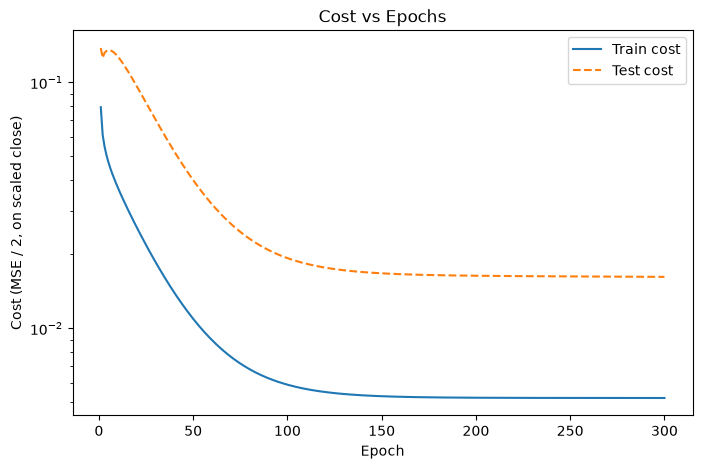

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_costs, label="Train cost")
plt.plot(range(1, epochs + 1), test_costs, label="Test cost", linestyle="--")
plt.title("Cost vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE / 2, on scaled close)")
plt.yscale("log")
plt.legend()
plt.savefig("cost_plot.png", dpi=150)
plt.show()

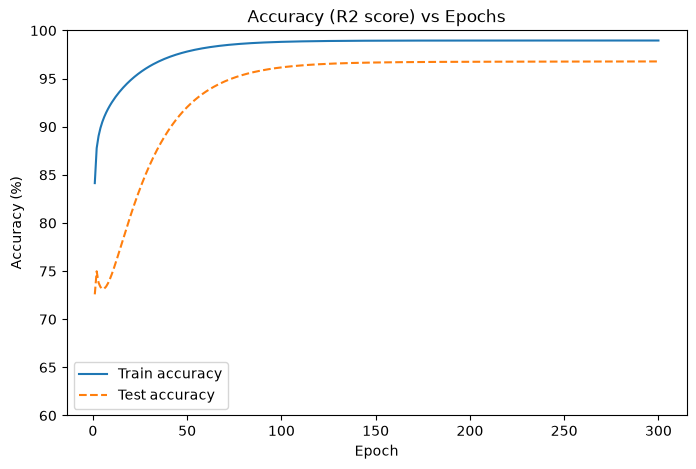

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accs, label="Train accuracy")
plt.plot(range(1, epochs + 1), test_accs, label="Test accuracy", linestyle="--")
plt.title("Accuracy (R2 score) vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(60, 100)
plt.legend()
plt.savefig("accuracy_plot.png", dpi=150)
plt.show()

In [17]:
final_pred = predict(X_test, w) * y_std + y_mean
mae = np.abs(y_test - final_pred).mean()
rmse = np.sqrt(((y_test - final_pred) ** 2).mean())

print("Final train accuracy (R2):", round(train_accs[-1], 2), "%")
print("Final test accuracy  (R2):", round(test_accs[-1], 2), "%")
print("Average error (MAE):", round(mae, 2))
print("RMSE:", round(rmse, 2))

Final train accuracy (R2): 98.96 %
Final test accuracy  (R2): 96.79 %
Average error (MAE): 10.36
RMSE: 13.52
